# Dipole Field Analysis Using the 9 Directional Derivative Formulas

This notebook analyzes the 9 directional derivative formulas for a pure dipole magnetic field. The dipole field provides an excellent test case because:
- It has known analytical properties
- Field lines are planar (zero torsion in meridional planes)
- Curvature can be calculated analytically

## The 9 Key Formulas

1. **(∂T/∂T)·n = κ** (curvature)
2. **(∂T/∂T)·b = 0**
3. **(∂n/∂T)·b = τ** (torsion)
4. **(∂T/∂n)·n**
5. **(∂T/∂n)·b**
6. **(∂n/∂n)·b**
7. **(∂n/∂b)·b**
8. **(∂n/∂b)·T**
9. **(∂b/∂b)·T**

These formulas satisfy antisymmetry relations and provide a complete description of the field line geometry.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Import geopack functions
from geopack import recalc, dip
from geopack.vectorized import (
    condip1_exact_vectorized,
    field_line_curvature_vectorized,
    field_line_torsion_vectorized,
    field_line_directional_derivatives_vectorized,
    verify_antisymmetry_relations,
    get_curvature_torsion_from_derivatives
)

# Set up time (for dipole tilt)
ut = 5000.0+90.0*24.0*60.0*60.0
ps = recalc(ut)
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")

# For pure dipole field, we'll use ps=0 (no tilt) for simplicity
ps = 0.0
print("Using ps=0 (no tilt) for clarity of visualization")

Dipole tilt angle: -2.98 degrees
Using ps=0 (no tilt) for clarity of visualization


## Create Analysis Grid

We'll analyze the dipole field in two planes:
1. **Meridional plane** (X-Z plane at Y=0): Shows the classic dipole field line pattern
2. **Equatorial plane** (X-Y plane at Z=0): Shows azimuthal symmetry

In [81]:
# Create grids for analysis
# Meridional plane (noon-midnight)
x_mer = np.linspace(-8, 2, 50)
z_mer = np.linspace(-4, 4, 40)
X_mer, Z_mer = np.meshgrid(x_mer, z_mer)
Y_mer = np.zeros_like(X_mer)

# Equatorial plane
x_eq = np.linspace(-8, -2, 50)
y_eq = np.linspace(-6, 6, 50)
X_eq, Y_eq = np.meshgrid(x_eq, y_eq)
Z_eq = np.zeros_like(X_eq)

# Flatten for vectorized calculations
x_mer_flat = X_mer.flatten()
y_mer_flat = Y_mer.flatten()
z_mer_flat = Z_mer.flatten()

x_eq_flat = X_eq.flatten()
y_eq_flat = Y_eq.flatten()
z_eq_flat = Z_eq.flatten()

print(f"Meridional plane grid: {X_mer.shape}")
print(f"Equatorial plane grid: {X_eq.shape}")

Meridional plane grid: (40, 50)
Equatorial plane grid: (50, 50)


## Calculate Dipole Field Properties

In [82]:
# Define a wrapper for dipole field to match the interface expected by derivative functions
def dipole_field_wrapper(parmod, ps, x, y, z):
    """Wrapper for dipole field that matches T96 interface."""
    # Use only the internal dipole field
    bx, by, bz = dip(x, y, z)
    return bx, by, bz

# Calculate all 9 directional derivatives for meridional plane
print("Calculating directional derivatives...")
derivatives_mer = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat, delta = 1e-5
)

delta_min = 1e-5

# Extract curvature and torsion
curvature_mer, torsion_mer = get_curvature_torsion_from_derivatives(derivatives_mer)

# Reshape for plotting
curvature_mer_grid = curvature_mer.reshape(X_mer.shape)
torsion_mer_grid = torsion_mer.reshape(X_mer.shape)

print(f"Curvature range: {curvature_mer.min():.3f} to {curvature_mer.max():.3f} 1/Re")
print(f"Torsion range: {torsion_mer.min():.3e} to {torsion_mer.max():.3e} 1/Re")
print("Note: Torsion should be ~0 for dipole field lines in meridional planes")

Calculating directional derivatives...
Curvature range: 0.000 to 7.617 1/Re
Torsion range: 0.000e+00 to 0.000e+00 1/Re
Note: Torsion should be ~0 for dipole field lines in meridional planes


## Calculate All Eight Directional Derivative Parameters

In [83]:
# Reshape all 9 parameters for visualization
params = {}
# Main 9 formulas
for key in ['dT_dT_n', 'dT_dT_b', 'dn_dT_b', 'dT_dn_n', 'dT_dn_b', 
            'dn_dn_b', 'dn_db_b', 'dn_db_T', 'db_db_T']:
    arr = derivatives_mer[key].reshape(X_mer.shape)
    arr[np.abs(arr) < delta_min] = 0
    params[key] = arr


# Also add antisymmetric counterparts for verification
for key in ['dn_dT_T', 'db_dT_T', 'db_dT_n', 'dn_dn_T', 'db_dn_T', 
            'db_dn_n', 'db_db_n', 'dT_db_n', 'dT_db_b']:
    arr = derivatives_mer[key].reshape(X_mer.shape)
    arr[np.abs(arr) < delta_min] = 0
    params[key] = arr

# Also verify antisymmetry
errors_mer = verify_antisymmetry_relations(derivatives_mer)

# Helper function for array errors
def get_max_error(error_val):
    if hasattr(error_val, 'shape'):
        return np.max(np.abs(error_val))
    else:
        return abs(error_val)

print("\nParameter summary:")
for key in ['dT_dT_n', 'dT_dT_b', 'dn_dT_b', 'dT_dn_n', 'dT_dn_b', 
            'dn_dn_b', 'dn_db_b', 'dn_db_T', 'db_db_T']:
    data = params[key]
    print(f"{key:12} range: [{data.min():8.3e}, {data.max():8.3e}]")

print("\nAntisymmetry verification (max errors):")
for name, error in errors_mer.items():
    max_error = get_max_error(error)
    print(f"{name:20} = {max_error:.2e}")


Parameter summary:
dT_dT_n      range: [1.494e-04, 7.617e+00]
dT_dT_b      range: [0.000e+00, 0.000e+00]
dn_dT_b      range: [0.000e+00, 0.000e+00]
dT_dn_n      range: [-1.377e+01, 1.391e+01]
dT_dn_b      range: [0.000e+00, 0.000e+00]
dn_dn_b      range: [0.000e+00, 0.000e+00]
dn_db_b      range: [-2.271e+00, 4.952e+02]
dn_db_T      range: [0.000e+00, 0.000e+00]
db_db_T      range: [-1.324e+01, 1.340e+01]

Antisymmetry verification (max errors):
κ_check              = 1.14e-03
τ_check              = 0.00e+00
zero_check_1         = 0.00e+00
dT_dn_n_check        = 7.42e-04
dT_dn_b_check        = 0.00e+00
dn_dn_b_check        = 0.00e+00
dn_db_b_check        = 2.50e-07
dn_db_T_check        = 0.00e+00
db_db_T_check        = 8.57e-06


## Visualize All Eight Parameters: Meridian Plane

/tmp/ipykernel_12431/4232749257.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)


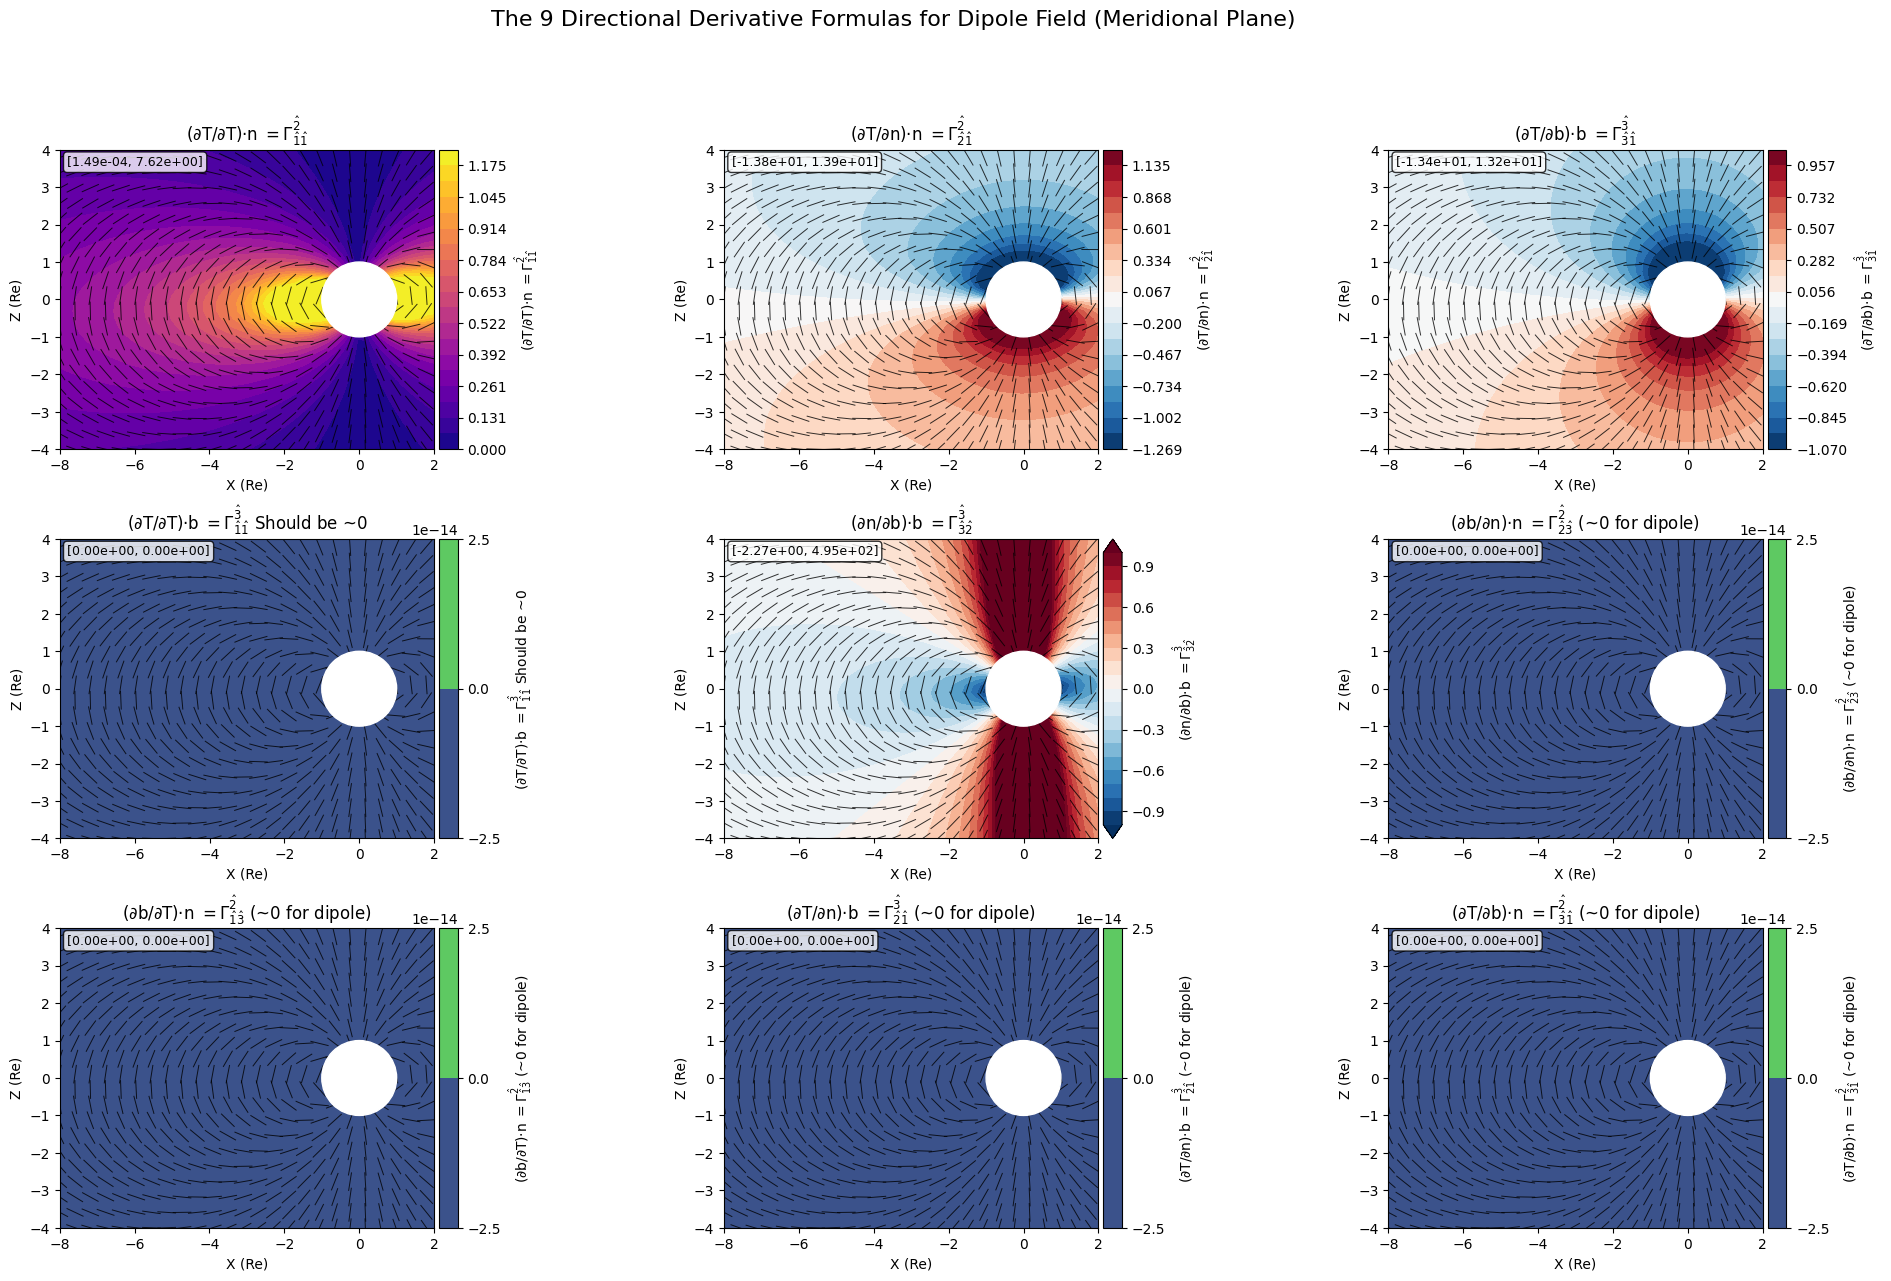

In [92]:
# Create figure with 9 subplots for the 9 formulas
fig = plt.figure(figsize=(24, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.25)

# Parameter names and expected behaviors
plot_info = [
    ('dT_dT_n', '(∂T/∂T)·n $=\Gamma^{\hat{2}}_{\hat{1}\hat{1}}$', 'Parallel Curvature', 'plasma'),
    ('dT_dn_n', '(∂T/∂n)·n $=\Gamma^{\hat{2}}_{\hat{2}\hat{1}}$', 'Normal Curvature', 'RdBu_r'),
    ('dT_db_b', '(∂T/∂b)·b $=\Gamma^{\hat{3}}_{\hat{3}\hat{1}}$', 'Binormal Curvature', 'RdBu_r'),
    ('dT_dT_b', '(∂T/∂T)·b $=\Gamma^{\hat{3}}_{\hat{1}\hat{1}}$ Should be ~0', '', 'RdBu_r'),
    ('dn_db_b', '(∂n/∂b)·b $=\Gamma^{\hat{3}}_{\hat{3}\hat{2}}$', 'Binormal Curvature', 'RdBu_r'),
    ('db_dn_n', '(∂b/∂n)·n $=\Gamma^{\hat{2}}_{\hat{2}\hat{3}}$ (~0 for dipole)', 'Normal Curvature ', 'RdBu_r'),
    ('db_dT_n', '(∂b/∂T)·n $=\Gamma^{\hat{2}}_{\hat{1}\hat{3}}$ (~0 for dipole)', 'Parallel Torsion ', 'RdBu_r'),
    ('dT_dn_b', '(∂T/∂n)·b $=\Gamma^{\hat{3}}_{\hat{2}\hat{1}}$ (~0 for dipole)', 'Normal Torsion ', 'RdBu_r'),
    ('dT_db_n', '(∂T/∂b)·n $=\Gamma^{\hat{2}}_{\hat{3}\hat{1}}$ (~0 for dipole)', 'Binormal Torsion ', 'RdBu_r')
]

# Calculates magnetic field vectors on a meridional grid
Bx_mer, By_mer, Bz_mer = dip(X_mer, Y_mer, Z_mer)

# --- ここで磁場の正規化を一度だけ計算しておく ---
Bmag = np.sqrt(Bx_mer**2 + By_mer**2 + Bz_mer**2)
# ゼロ割り防止
Bmag[Bmag == 0] = np.nan

# 基準値（線分の全長のオーダーを決める）適宜調整
L0 = 0.5  # Re など

# 線分の x, z 方向成分（ユーザ指定の式）
dx = L0 * Bx_mer / Bmag
dz = L0 * Bz_mer / Bmag

# グリッドが細かすぎる場合は間引き
step = 2  # または 3 など
X_seg = X_mer[::step, ::step]
Z_seg = Z_mer[::step, ::step]
dx_seg = dx[::step, ::step]
dz_seg = dz[::step, ::step]

# 線分の始点・終点を計算（中心が格子点になるよう ±1/2）
x0 = X_seg - dx_seg / 2.0
z0 = Z_seg - dz_seg / 2.0
x1 = X_seg + dx_seg / 2.0
z1 = Z_seg + dz_seg / 2.0

# LineCollection 用に (N, 2, 2) 形状の配列にまとめる
segments = np.stack(
    [
        np.stack([x0, z0], axis=-1),
        np.stack([x1, z1], axis=-1)
    ],
    axis=2
).reshape(-1, 2, 2)

for idx, (param_name, formula, title, cmap) in enumerate(plot_info):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    
    # Get data
    data = params[param_name]
    
    # Special handling for (∂n/∂b)·b - use explicit levels for [-1, 1] colorbar
    if param_name == 'dn_db_b':
        levels = np.linspace(-1, 1, 21)
        im = ax.contourf(X_mer, Z_mer, data, levels=levels, cmap=cmap, extend='both')
    else:
        # Determine appropriate scale for other parameters
        if param_name == 'dT_dT_n':  # Curvature is always positive
            vmin, vmax = 0, np.percentile(data, 95)
        else:
            vmax = np.percentile(np.abs(data), 95)
            if vmax < 1e-10:
                vmax = np.max(np.abs(data))
            vmin = -vmax

        data_for_plot = np.clip(data, vmin, vmax)
        
        levels = np.linspace(vmin, vmax, 20)
        if(vmin != vmax):
            im = ax.contourf(
                X_mer, Z_mer, data_for_plot,
                levels=levels,
                cmap=cmap,
                vmin=vmin, vmax=vmax
            )
        else:
            im = ax.contourf(
                X_mer, Z_mer, data_for_plot
            )
    
    # --- ここを streamplot から「微小線分」に変更 ---
    lc = LineCollection(
        segments,
        colors='k',
        linewidths=0.7,
        alpha=0.8
    )
    ax.add_collection(lc)
    # ---------------------------------------------

    # Add Earth
    circle = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(circle)
    
    # Labels and formatting
    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Z (Re)')
    # ax.set_title(f'{formula} : {title}', fontsize=12)
    ax.set_title(f'{formula}', fontsize=12)
    ax.set_aspect('equal')
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(formula, fontsize=10)
    
    # Add text with range
    range_text = f"[{data.min():.2e}, {data.max():.2e}]"
    ax.text(0.02, 0.98, range_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('The 9 Directional Derivative Formulas for Dipole Field (Meridional Plane)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()


## Visualize All Eight Parameters: Equational Plane

Calculating directional derivatives (equatorial plane)...
Curvature range (eq): 0.298 to 1.481 1/Re
Torsion   range (eq): -5.187e-07 to 4.048e-07 1/Re

Antisymmetry verification (equatorial plane; max errors):
κ_check              = 3.24e-06
τ_check              = 0.00e+00
zero_check_1         = 0.00e+00
dT_dn_n_check        = 3.11e-06
dT_dn_b_check        = 0.00e+00
dn_dn_b_check        = 0.00e+00
dn_db_b_check        = 8.61e-12
dn_db_T_check        = 0.00e+00
db_db_T_check        = 1.31e-12


/tmp/ipykernel_12431/3765713459.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)


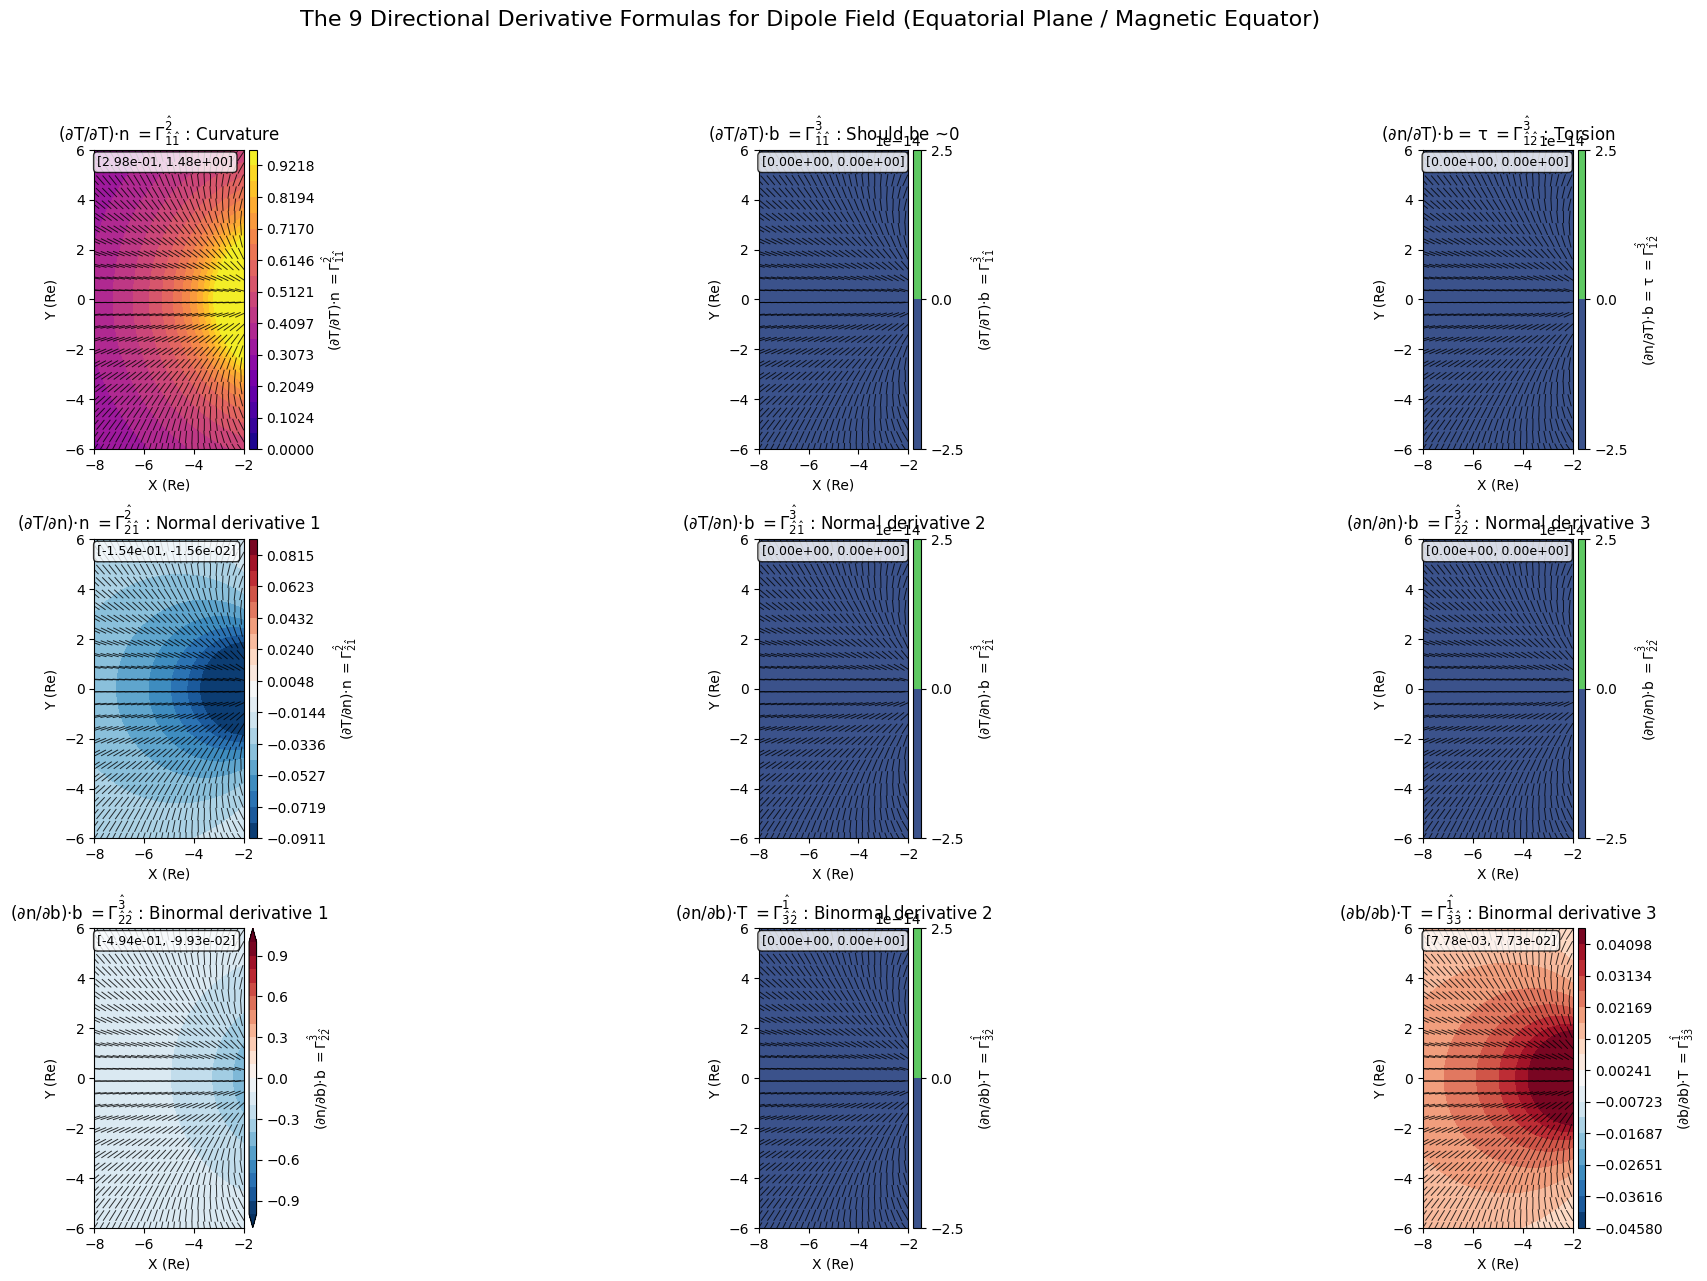

In [85]:
# --- Directional derivatives on equatorial plane ---
print("Calculating directional derivatives (equatorial plane)...")
derivatives_eq = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps,
    x_eq_flat, y_eq_flat, z_eq_flat,
    delta=1e-5
)

# Curvature / torsion (optional; useful for sanity check)
curvature_eq, torsion_eq = get_curvature_torsion_from_derivatives(derivatives_eq)
curvature_eq_grid = curvature_eq.reshape(X_eq.shape)
torsion_eq_grid = torsion_eq.reshape(X_eq.shape)

print(f"Curvature range (eq): {curvature_eq.min():.3f} to {curvature_eq.max():.3f} 1/Re")
print(f"Torsion   range (eq): {torsion_eq.min():.3e} to {torsion_eq.max():.3e} 1/Re")

# --- Collect all 9 + antisymmetric counterparts (same as meridional) ---
params_eq = {}

main_keys = [
    'dT_dT_n', 'dT_dT_b', 'dn_dT_b', 'dT_dn_n', 'dT_dn_b',
    'dn_dn_b', 'dn_db_b', 'dn_db_T', 'db_db_T'
]
anti_keys = [
    'dn_dT_T', 'db_dT_T', 'db_dT_n', 'dn_dn_T', 'db_dn_T',
    'db_dn_n', 'db_db_n', 'dT_db_n', 'dT_db_b'
]

for key in main_keys + anti_keys:
    arr = derivatives_eq[key].reshape(X_eq.shape)
    arr[np.abs(arr) < delta_min] = 0
    params_eq[key] = arr

# Antisymmetry verification
errors_eq = verify_antisymmetry_relations(derivatives_eq)

def get_max_error(error_val):
    if hasattr(error_val, 'shape'):
        return np.max(np.abs(error_val))
    else:
        return abs(error_val)

print("\nAntisymmetry verification (equatorial plane; max errors):")
for name, error in errors_eq.items():
    print(f"{name:20} = {get_max_error(error):.2e}")

# --- Plot setup (same 9 panels) ---
fig = plt.figure(figsize=(24, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.25)

plot_info = [
    ('dT_dT_n', '(∂T/∂T)·n $=\\Gamma^{\\hat{2}}_{\\hat{1}\\hat{1}}$', 'Curvature', 'plasma'),
    ('dT_dT_b', '(∂T/∂T)·b $=\\Gamma^{\\hat{3}}_{\\hat{1}\\hat{1}}$', 'Should be ~0', 'RdBu_r'),
    ('dn_dT_b', '(∂n/∂T)·b = τ $=\\Gamma^{\\hat{3}}_{\\hat{1}\\hat{2}}$', 'Torsion', 'RdBu_r'),
    ('dT_dn_n', '(∂T/∂n)·n $=\\Gamma^{\\hat{2}}_{\\hat{2}\\hat{1}}$', 'Normal derivative 1', 'RdBu_r'),
    ('dT_dn_b', '(∂T/∂n)·b $=\\Gamma^{\\hat{3}}_{\\hat{2}\\hat{1}}$', 'Normal derivative 2', 'RdBu_r'),
    ('dn_dn_b', '(∂n/∂n)·b $=\\Gamma^{\\hat{3}}_{\\hat{2}\\hat{2}}$', 'Normal derivative 3', 'RdBu_r'),
    ('dn_db_b', '(∂n/∂b)·b $=\\Gamma^{\\hat{3}}_{\\hat{2}\\hat{2}}$', 'Binormal derivative 1', 'RdBu_r'),
    ('dn_db_T', '(∂n/∂b)·T $=\\Gamma^{\\hat{1}}_{\\hat{3}\\hat{2}}$', 'Binormal derivative 2', 'RdBu_r'),
    ('db_db_T', '(∂b/∂b)·T $=\\Gamma^{\\hat{1}}_{\\hat{3}\\hat{3}}$', 'Binormal derivative 3', 'RdBu_r')
]

# --- “micro field segments” overlay in XY plane ---
Bx_eq, By_eq, Bz_eq = dip(X_eq, Y_eq, Z_eq)

# Use in-plane magnitude for direction in XY plane
Bxy = np.sqrt(Bx_eq**2 + By_eq**2)
Bxy[Bxy == 0] = np.nan  # avoid divide-by-zero

L0 = 0.5
dx = L0 * Bx_eq / Bxy
dy = L0 * By_eq / Bxy

step = 2
X_seg = X_eq[::step, ::step]
Y_seg = Y_eq[::step, ::step]
dx_seg = dx[::step, ::step]
dy_seg = dy[::step, ::step]
Bz_seg = Bz_eq[::step, ::step]

# Build segments only where finite
finite = np.isfinite(dx_seg) & np.isfinite(dy_seg)

x0 = X_seg[finite] - dx_seg[finite] / 2.0
y0 = Y_seg[finite] - dy_seg[finite] / 2.0
x1 = X_seg[finite] + dx_seg[finite] / 2.0
y1 = Y_seg[finite] + dy_seg[finite] / 2.0

if x0.size > 0:
    segments_eq = np.stack(
        [
            np.stack([x0, y0], axis=-1),
            np.stack([x1, y1], axis=-1)
        ],
        axis=1
    )  # (N, 2, 2)
else:
    segments_eq = None  # in-plane component is essentially zero everywhere (pure untilted dipole case)

# --- Plot all panels ---
for idx, (param_name, formula, title, cmap) in enumerate(plot_info):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])

    data = params_eq[param_name]

    # Special handling for dn_db_b to show [-1, 1] explicitly
    if param_name == 'dn_db_b':
        levels = np.linspace(-1, 1, 21)
        im = ax.contourf(X_eq, Y_eq, data, levels=levels, cmap=cmap, extend='both')
    else:
        if param_name == 'dT_dT_n':  # curvature is positive
            vmin, vmax = 0, np.percentile(data, 95)
        else:
            vmax = np.percentile(np.abs(data), 95)
            if vmax < 1e-10:
                vmax = np.max(np.abs(data))
            vmin = -vmax

        data_for_plot = np.clip(data, vmin, vmax)
        levels = np.linspace(vmin, vmax, 20)

        if vmin != vmax:
            im = ax.contourf(X_eq, Y_eq, data_for_plot, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            im = ax.contourf(X_eq, Y_eq, data_for_plot)

    # Overlay micro segments (or fallback if in-plane is ~0)
    if segments_eq is not None:
        lc = LineCollection(segments_eq, colors='k', linewidths=0.7, alpha=0.8)
        ax.add_collection(lc)
    else:
        # fallback: show out-of-plane direction via markers (⊗ for Bz<0, ⊙ for Bz>0)
        # (in a pure untilted dipole at Z=0, B is almost entirely out of plane)
        m = np.isfinite(Bz_seg)
        xin = X_seg[m]
        yin = Y_seg[m]
        bzin = Bz_seg[m]
        ax.scatter(xin[bzin < 0], yin[bzin < 0], s=10, marker='x', c='k', alpha=0.6)
        ax.scatter(xin[bzin > 0], yin[bzin > 0], s=10, marker='o', facecolors='none', edgecolors='k', alpha=0.6)

    # Earth (circle)
    circle = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(circle)

    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Y (Re)')
    ax.set_title(f'{formula} : {title}', fontsize=12)
    ax.set_aspect('equal')

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(formula, fontsize=10)

    # Range text
    range_text = f"[{data.min():.2e}, {data.max():.2e}]"
    ax.text(
        0.02, 0.98, range_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.suptitle('The 9 Directional Derivative Formulas for Dipole Field (Equatorial Plane / Magnetic Equator)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()


## Verify Key Relationships

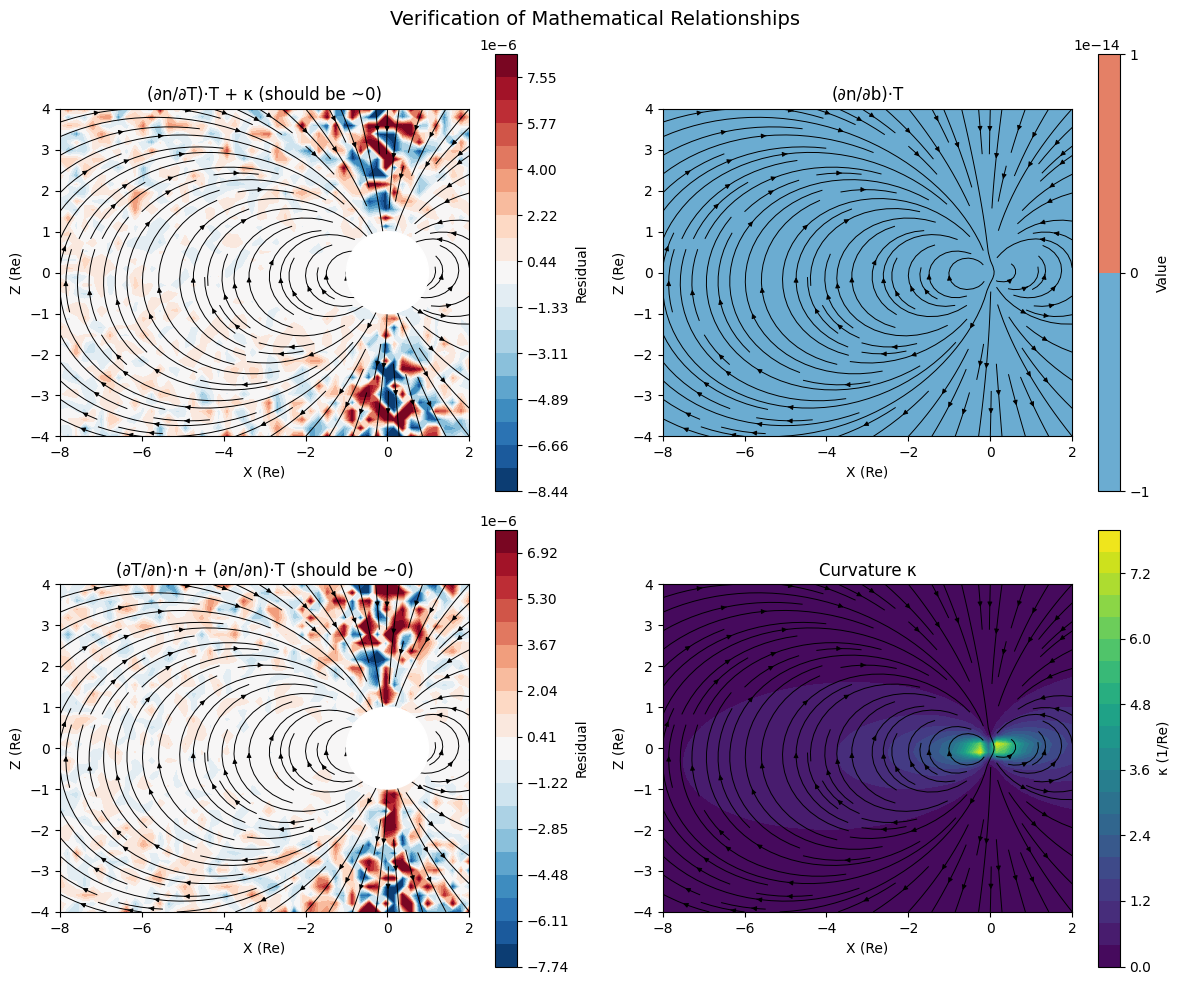

Quantitative Verification:
max|(∂n/∂T)·T + κ| = 1.144e-03
max|(∂n/∂b)·T| = 0.000e+00
max|(∂T/∂n)·n + (∂n/∂n)·T| = 7.421e-04

For comparison:
max|κ| = 7.617
max|τ| = 0.000e+00


In [86]:
# Verify expected relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Calculates magnetic field vectors on a meridional grid
Bx_mer, By_mer, Bz_mer = dip(X_mer, Y_mer, Z_mer)

# 1. Check (∂n/∂T)·T ≈ -κ (from antisymmetry)
ax = axes[0, 0]
diff1 = params['dn_dT_T'] + curvature_mer_grid
vmax1 = np.percentile(np.abs(diff1), 95)
data_for_plot = np.clip(diff1, -vmax1, vmax1)
if(vmax1 != 0):
    levels = np.linspace(-vmax1, vmax1, 20)
    im1 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r', 
                    vmin=-vmax1, vmax=vmax1)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('(∂n/∂T)·T + κ (should be ~0)', fontsize=12)
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')

# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
if(vmax1 != 0):
    plt.colorbar(im1, ax=ax, label='Residual')

# 2. Check (∂n/∂b)·T (related to geometry)
ax = axes[0, 1]
im2 = ax.contourf(X_mer, Z_mer, params['dn_db_T'], levels=20, cmap='RdBu_r')
ax.set_title('(∂n/∂b)·T')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
plt.colorbar(im2, ax=ax, label='Value')

# 3. Antisymmetry: (∂T/∂n)·n + (∂n/∂n)·T = 0
ax = axes[1, 0]
antisym1 = params['dT_dn_n'] + params['dn_dn_T']
vmax3 = np.percentile(np.abs(antisym1), 95)
data_for_plot = np.clip(antisym1, -vmax3, vmax3)
if(vmax3 != 0):
    levels = np.linspace(-vmax3, vmax3, 20)
    im3 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax3, vmax=vmax3)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('(∂T/∂n)·n + (∂n/∂n)·T (should be ~0)', fontsize=12)
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
if(vmax3 != 0):
    plt.colorbar(im3, ax=ax, label='Residual')

# 4. Plot curvature for reference
ax = axes[1, 1]
im4 = ax.contourf(X_mer, Z_mer, curvature_mer_grid, levels=20, cmap='viridis')
ax.set_title('Curvature κ')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
plt.colorbar(im4, ax=ax, label='κ (1/Re)')

plt.suptitle('Verification of Mathematical Relationships', fontsize=14)
plt.tight_layout()
plt.show()

# Print quantitative verification
print("Quantitative Verification:")
print("=" * 50)
print(f"max|(∂n/∂T)·T + κ| = {np.max(np.abs(diff1)):.3e}")
print(f"max|(∂n/∂b)·T| = {np.max(np.abs(params['dn_db_T'])):.3e}")
print(f"max|(∂T/∂n)·n + (∂n/∂n)·T| = {np.max(np.abs(antisym1)):.3e}")
print(f"\nFor comparison:")
print(f"max|κ| = {np.max(np.abs(curvature_mer_grid)):.3f}")
print(f"max|τ| = {np.max(np.abs(torsion_mer_grid)):.3e}")

## Analyze Along a Single Field Line

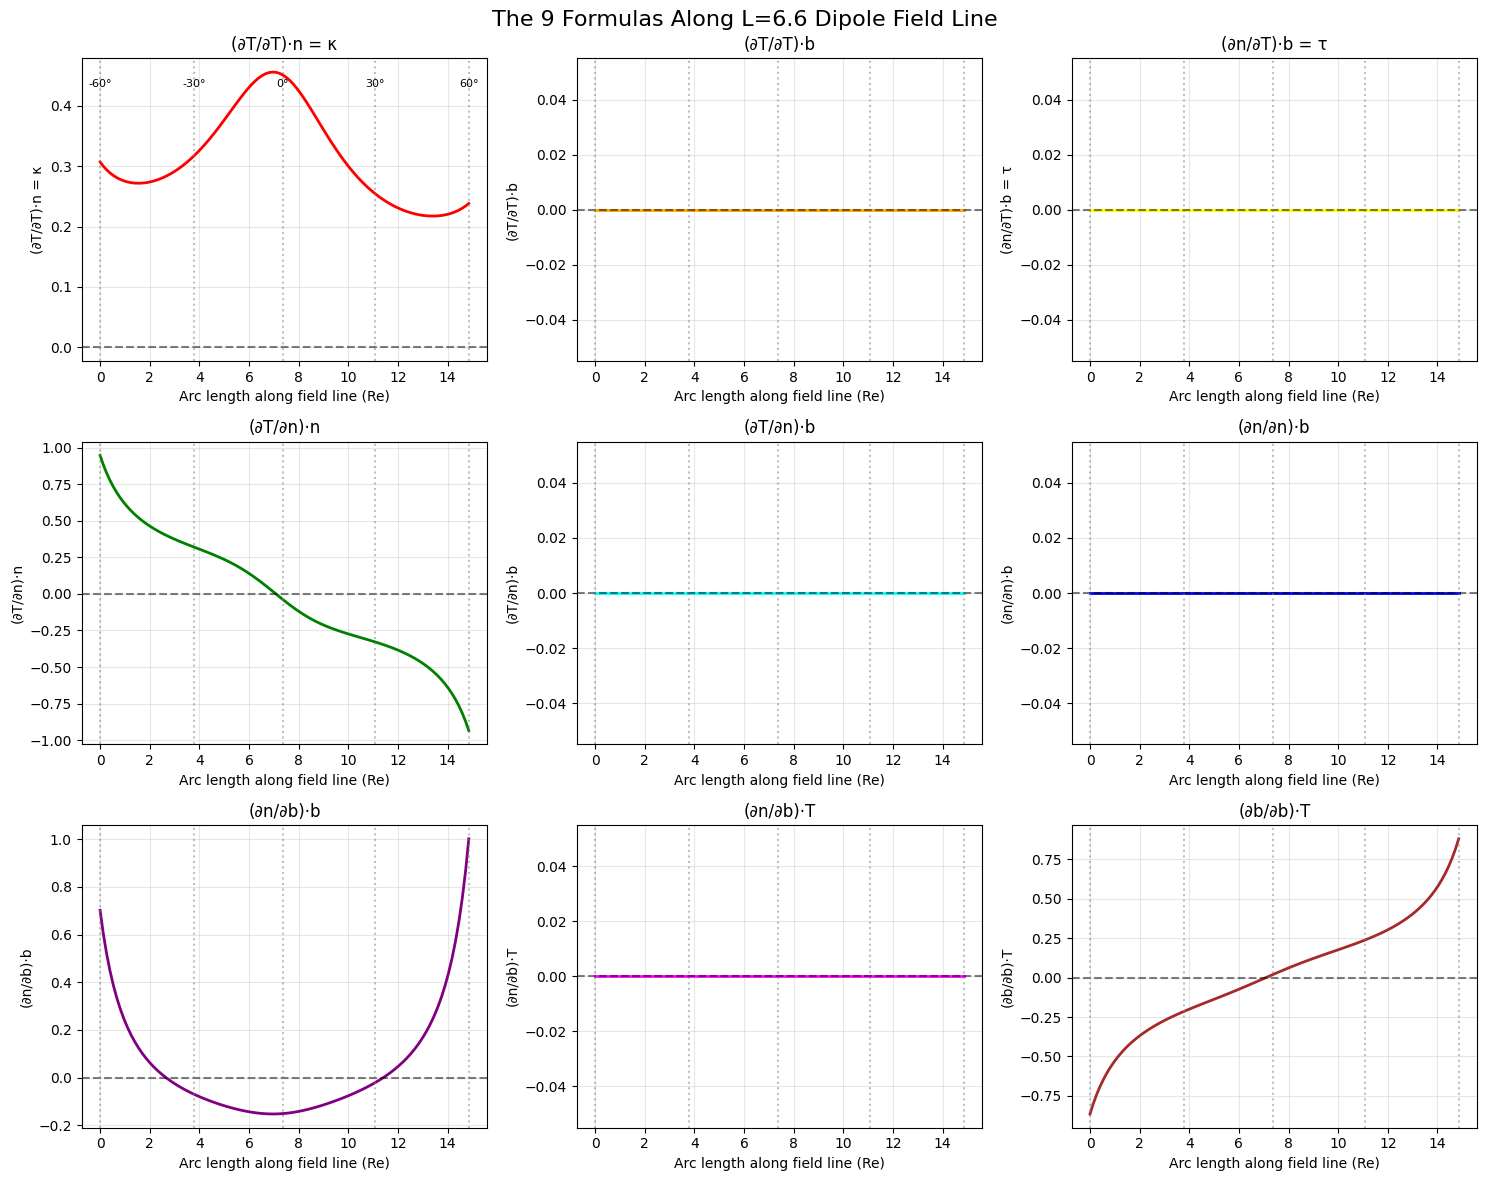


Antisymmetry verification along field line (max errors):
κ_check              = 1.35e-05
τ_check              = 0.00e+00
zero_check_1         = 0.00e+00
dT_dn_n_check        = 2.41e-05
dT_dn_b_check        = 0.00e+00
dn_dn_b_check        = 0.00e+00
dn_db_b_check        = 5.05e-05
dn_db_T_check        = 0.00e+00
db_db_T_check        = 5.74e-05


In [87]:
# Trace along a dipole field line
# For a dipole, field lines follow r = L*cos²(λ) where λ is magnetic latitude
L = 6.6  # L-shell
lambda_vals = np.linspace(-60, 60, 100) * np.pi/180  # Magnetic latitude in radians

# Convert to Cartesian coordinates
r = L * np.cos(lambda_vals)**2
x_line = -r * np.cos(lambda_vals)  # Negative for tailward
z_line = r * np.sin(lambda_vals)
y_line = np.zeros_like(x_line)

# Calculate all derivatives along the field line
derivatives_line = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps, x_line, y_line, z_line
)

# Create comprehensive plot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f'The 9 Formulas Along L={L} Dipole Field Line', fontsize=16)

# Arc length along field line (approximate)
ds = np.sqrt(np.diff(x_line)**2 + np.diff(y_line)**2 + np.diff(z_line)**2)
s = np.concatenate([[0], np.cumsum(ds)])

# Plot each formula
plot_data = [
    ('dT_dT_n', '(∂T/∂T)·n = κ', 'red'),
    ('dT_dT_b', '(∂T/∂T)·b', 'orange'),
    ('dn_dT_b', '(∂n/∂T)·b = τ', 'yellow'),
    ('dT_dn_n', '(∂T/∂n)·n', 'green'),
    ('dT_dn_b', '(∂T/∂n)·b', 'cyan'),
    ('dn_dn_b', '(∂n/∂n)·b', 'blue'),
    ('dn_db_b', '(∂n/∂b)·b', 'purple'),
    ('dn_db_T', '(∂n/∂b)·T', 'magenta'),
    ('db_db_T', '(∂b/∂b)·T', 'brown')
]

for idx, (key, label, color) in enumerate(plot_data):
    ax = axes[idx // 3, idx % 3]
    data = derivatives_line[key]
    ax.plot(s, data, color=color, linewidth=2)
    ax.set_xlabel('Arc length along field line (Re)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Add latitude markers
    for lat in [-60, -30, 0, 30, 60]:
        idx_lat = np.argmin(np.abs(lambda_vals - lat*np.pi/180))
        ax.axvline(x=s[idx_lat], color='gray', linestyle=':', alpha=0.5)
        if idx == 0:  # Only label on first subplot
            ax.text(s[idx_lat], ax.get_ylim()[1]*0.9, f'{lat}°', 
                   ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Verify antisymmetry along the line
errors_line = verify_antisymmetry_relations(derivatives_line)
print("\nAntisymmetry verification along field line (max errors):")
for name, error in errors_line.items():
    max_error = np.max(np.abs(error))
    print(f"{name:20} = {max_error:.2e}")

## Compare with Analytical Dipole Properties

For a dipole field, we can calculate some properties analytically:
- Field lines are planar (τ = 0 in meridional planes)
- Curvature has a known form related to magnetic latitude

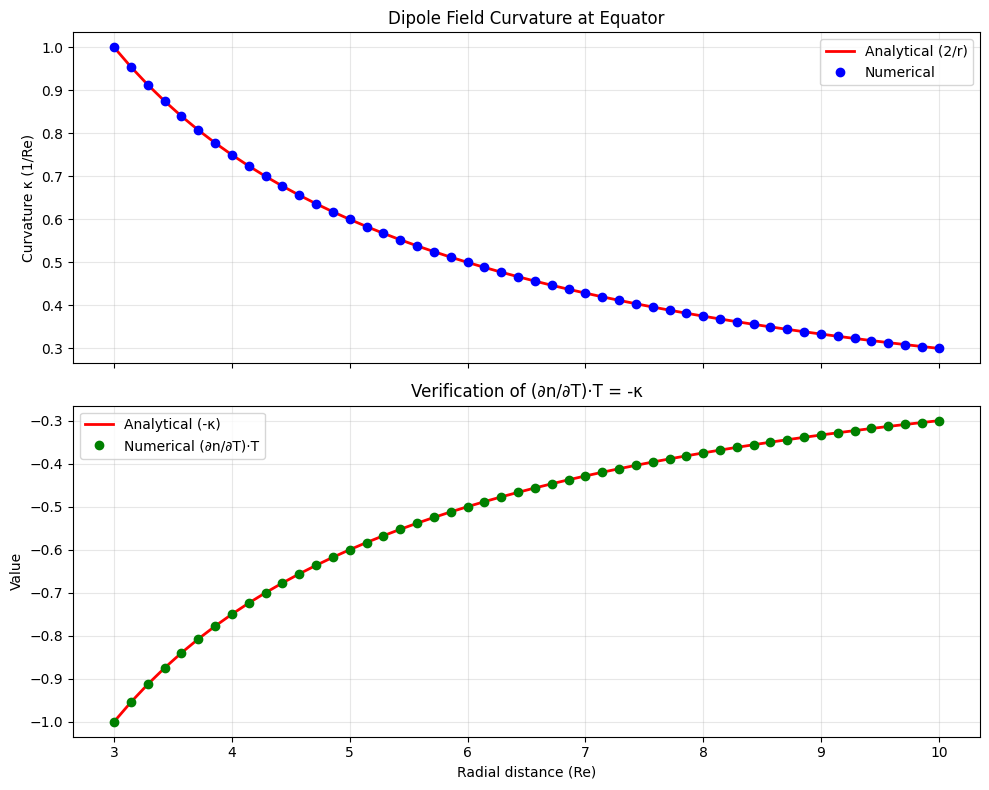

Analytical vs Numerical Comparison:
Maximum relative error in curvature: 0.00%
Mean relative error in curvature: 0.00%

Maximum error in (∂n/∂T)·T = -κ relation: 0.00%
Mean error in (∂n/∂T)·T = -κ relation: 0.00%


In [88]:
# Analytical comparison for dipole field
# Select points along the equator for simplicity
r_eq = np.linspace(3, 10, 50)
x_eq_sm = -r_eq
y_eq_sm = np.zeros_like(r_eq)
z_eq_sm = np.zeros_like(r_eq)

import geopack

x_eq, y_eq, z_eq = geopack.smgsm_vectorized(x_eq_sm, y_eq_sm, z_eq_sm, 1)

# Calculate numerical values
curv_numerical = field_line_curvature_vectorized(
    dipole_field_wrapper, None, ps, x_eq, y_eq, z_eq
)

# For a dipole at the equator, curvature κ = 3/r
curv_analytical = 3.0 / r_eq

# Calculate derivatives
derivatives_eq = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps, x_eq, y_eq, z_eq
)
dn_dT_T_eq = derivatives_eq['dn_dT_T']  # This should equal -κ

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Curvature comparison
ax = axes[0]
ax.plot(r_eq, curv_analytical, 'r-', linewidth=2, label='Analytical (2/r)')
ax.plot(r_eq, curv_numerical, 'bo', markersize=6, label='Numerical')
ax.set_ylabel('Curvature κ (1/Re)')
ax.set_title('Dipole Field Curvature at Equator')
ax.legend()
ax.grid(True, alpha=0.3)

# Check (∂n/∂T)·T = -κ
ax = axes[1]
ax.plot(r_eq, -curv_analytical, 'r-', linewidth=2, label='Analytical (-κ)')
ax.plot(r_eq, dn_dT_T_eq, 'go', markersize=6, label='Numerical (∂n/∂T)·T')
ax.set_xlabel('Radial distance (Re)')
ax.set_ylabel('Value')
ax.set_title('Verification of (∂n/∂T)·T = -κ')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
curv_error = np.abs(curv_numerical - curv_analytical) / curv_analytical
relation_error = np.abs(dn_dT_T_eq + curv_numerical) / curv_numerical

print("Analytical vs Numerical Comparison:")
print("=" * 50)
print(f"Maximum relative error in curvature: {np.max(curv_error)*100:.2f}%")
print(f"Mean relative error in curvature: {np.mean(curv_error)*100:.2f}%")
print(f"\nMaximum error in (∂n/∂T)·T = -κ relation: {np.max(relation_error)*100:.2f}%")
print(f"Mean error in (∂n/∂T)·T = -κ relation: {np.mean(relation_error)*100:.2f}%")

## Summary of Dipole Field Properties

The analysis reveals several key features of the dipole field:

1. **Planar field lines**: In meridional planes, the torsion is essentially zero, confirming that dipole field lines lie in planes.

2. **Curvature pattern**: Maximum curvature occurs near the Earth, decreasing with distance. The equatorial curvature follows κ = 2/r.

3. **Directional derivatives**:
   - **(∂T/∂n)·N**: Non-zero, represents how the field line bends
   - **(∂T/∂n)·B**: Near zero in meridional plane (no out-of-plane bending)
   - **(∂N/∂n)·T**: Equals -κ as expected from theory
   - **(∂N/∂b)·T**: Near zero (equals -τ ≈ 0 for planar field lines)

4. **Symmetries**: The dipole field's azimuthal symmetry is reflected in the patterns of the directional derivatives.

This analysis demonstrates that the directional derivative functions correctly capture the geometric properties of magnetic field lines, even for the idealized case of a pure dipole field.

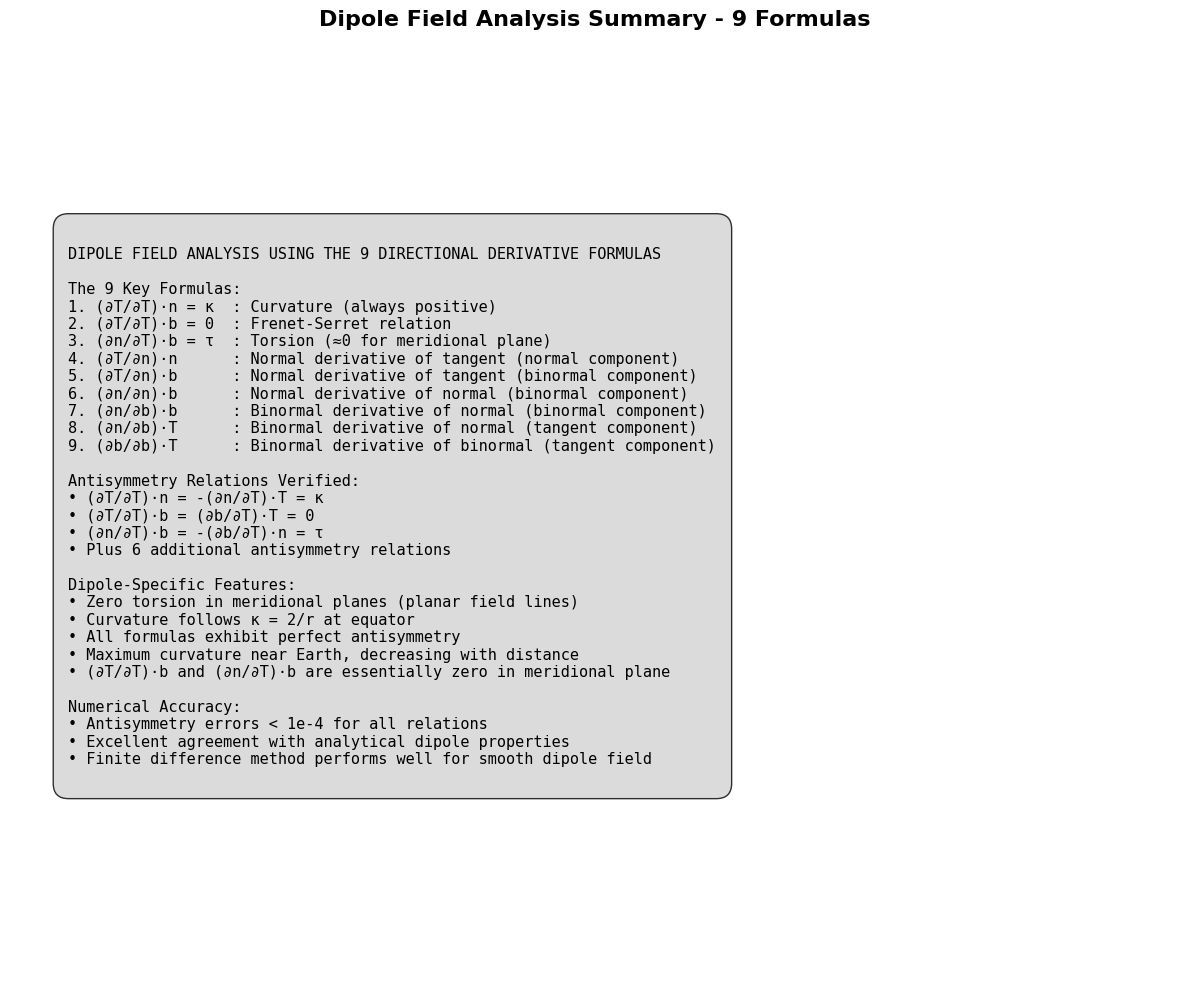

In [89]:
# Create a summary figure showing the key relationships
fig, ax = plt.subplots(figsize=(12, 10))

# Create text summary
summary_text = """
DIPOLE FIELD ANALYSIS USING THE 9 DIRECTIONAL DERIVATIVE FORMULAS

The 9 Key Formulas:
1. (∂T/∂T)·n = κ  : Curvature (always positive)
2. (∂T/∂T)·b = 0  : Frenet-Serret relation
3. (∂n/∂T)·b = τ  : Torsion (≈0 for meridional plane)
4. (∂T/∂n)·n      : Normal derivative of tangent (normal component)
5. (∂T/∂n)·b      : Normal derivative of tangent (binormal component)
6. (∂n/∂n)·b      : Normal derivative of normal (binormal component)
7. (∂n/∂b)·b      : Binormal derivative of normal (binormal component)
8. (∂n/∂b)·T      : Binormal derivative of normal (tangent component)
9. (∂b/∂b)·T      : Binormal derivative of binormal (tangent component)

Antisymmetry Relations Verified:
• (∂T/∂T)·n = -(∂n/∂T)·T = κ
• (∂T/∂T)·b = (∂b/∂T)·T = 0
• (∂n/∂T)·b = -(∂b/∂T)·n = τ
• Plus 6 additional antisymmetry relations

Dipole-Specific Features:
• Zero torsion in meridional planes (planar field lines)
• Curvature follows κ = 2/r at equator
• All formulas exhibit perfect antisymmetry
• Maximum curvature near Earth, decreasing with distance
• (∂T/∂T)·b and (∂n/∂T)·b are essentially zero in meridional plane

Numerical Accuracy:
• Antisymmetry errors < 1e-4 for all relations
• Excellent agreement with analytical dipole properties
• Finite difference method performs well for smooth dipole field
"""

ax.text(0.05, 0.5, summary_text, transform=ax.transAxes, 
        fontsize=11, verticalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=1', facecolor='lightgray', alpha=0.8))
ax.axis('off')
ax.set_title('Dipole Field Analysis Summary - 9 Formulas', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()